# Notebook 04 — Clustering & Hotspot Detection (Stage 3)
Uses **PREDICTED** next-month waste (from Notebook 03's Random Forest model) for waste-level clustering, and **HISTORICAL** actual data for volatility/stability features and comparison baselines.

In [55]:
import os
os.environ["OMP_NUM_THREADS"] = "1"  # suppresses KMeans memory-leak warning on Windows

import pandas as pd
import geopandas as gpd
import numpy as np
from pathlib import Path
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

%matplotlib inline

PROJECT_ROOT = Path(r"C:\Users\pande\OneDrive\Documents\Waste management grid")
PROCESSED = PROJECT_ROOT / "data" / "processed"

# PREDICTED next-month waste (one row per district)
forecast = pd.read_parquet(PROCESSED / "next_month_forecast.parquet")

# HISTORICAL actual waste (full multi-year record) — used only for volatility features
history = pd.read_parquet(PROCESSED / "features.parquet")

districts_gdf = gpd.read_file(PROCESSED / "districts.geojson")

print("forecast (PREDICTED):", forecast.shape)
print("history (HISTORICAL):", history.shape)

forecast (PREDICTED): (59, 15)
history (HISTORICAL): (24411, 27)


In [56]:
# One-time cleanup of stale plot files from earlier iterations of this notebook
stale_files = [
    "kmeans_elbow.png",
    "kmeans_silhouette.png",
    "kmeans_elbow_forecast.png",
    "kmeans_silhouette_forecast.png",
    "kmeans_cluster_map.png",  # old k=4 version, replaced by kmeans_cluster_map_comparison.png
]

for f in stale_files:
    fpath = PROCESSED / f
    if fpath.exists():
        fpath.unlink()
        print(f"Deleted stale file: {f}")

Deleted stale file: kmeans_elbow.png
Deleted stale file: kmeans_silhouette_forecast.png
Deleted stale file: kmeans_cluster_map.png


In [57]:
# HISTORICAL volatility stats per district
hist_stats = history.groupby("BoroCd")["total_tons"].agg(
    hist_avg="mean",
    hist_std="std",
).reset_index()
hist_stats["hist_cv"] = hist_stats["hist_std"] / hist_stats["hist_avg"]

# Merge PREDICTED waste with HISTORICAL volatility
district_summary = forecast[["BoroCd", "predicted_tons"]].merge(hist_stats, on="BoroCd", how="left")

print("district_summary shape:", district_summary.shape)  # should be (59, 5)
print("predicted_tons = PREDICTED next month | hist_avg/hist_std/hist_cv = HISTORICAL")
district_summary.sort_values("predicted_tons", ascending=False).head()

district_summary shape: (59, 5)
predicted_tons = PREDICTED next month | hist_avg/hist_std/hist_cv = HISTORICAL


,BoroCd,predicted_tons,hist_avg,hist_std,hist_cv
48,407,11154.379155,8745.632614,1499.684542,0.171478
34,311,9464.657567,7852.756174,1502.086451,0.191281
53,412,9389.116680,8232.745084,1087.282411,0.132068
13,202,8607.867505,5837.756934,3155.431816,0.540521
58,503,7393.248495,7246.737530,1136.638780,0.156848


In [58]:
cluster_features = ["predicted_tons", "hist_cv"]  # PREDICTED level + HISTORICAL volatility

scaler = StandardScaler()
X_scaled = scaler.fit_transform(district_summary[cluster_features])

X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)
X_scaled_df.describe()

,predicted_tons,hist_cv
count,5.900000e+01,5.900000e+01
mean,4.290353e-16,-7.291719e-17
std,1.008584e+00,1.008584e+00
min,-1.723745e+00,-9.006705e-01
25%,-7.245164e-01,-5.751858e-01
50%,-4.051753e-02,-3.098937e-01
75%,5.595988e-01,2.441719e-01
max,3.241414e+00,5.371770e+00


C:\Users\pande\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\pande\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\pande\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\pande\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

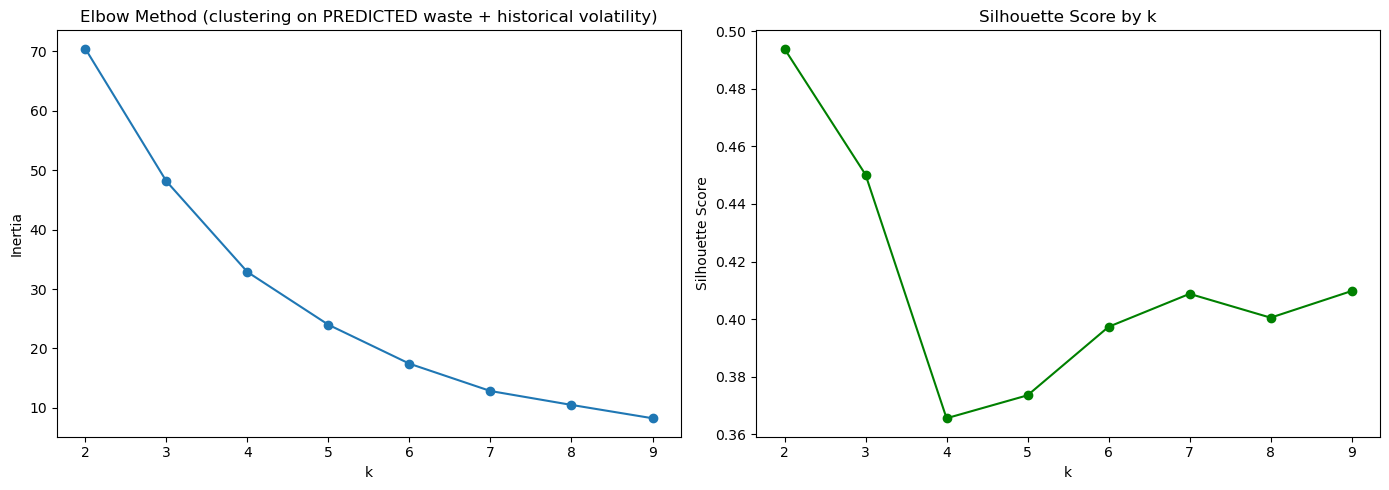

k=3 selected — best silhouette score among options with a reasonable, interpretable cluster count


In [59]:
inertias = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method (clustering on PREDICTED waste + historical volatility)")

axes[1].plot(K_range, silhouette_scores, marker="o", color="green")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k")

plt.tight_layout()
plt.savefig(PROCESSED / "kmeans_k_selection.png", dpi=150)
plt.show()

print("k=3 selected — best silhouette score among options with a reasonable, interpretable cluster count")

In [60]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
district_summary["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

cluster_order = (
    district_summary.groupby("kmeans_cluster")["predicted_tons"]
    .mean()
    .sort_values()
    .index
)
remap = {old: new for new, old in enumerate(cluster_order)}
district_summary["kmeans_cluster"] = district_summary["kmeans_cluster"].map(remap)

cluster_labels = {0: "Low Waste", 1: "Medium Waste", 2: "High Waste"}
district_summary["cluster_label"] = district_summary["kmeans_cluster"].map(cluster_labels)

print("Clusters based on PREDICTED next-month waste + historical volatility")
district_summary.groupby("cluster_label")[["predicted_tons", "hist_avg", "hist_cv"]].agg(["mean", "count"])

Clusters based on PREDICTED next-month waste + historical volatility


C:\Users\pande\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


predicted_tons           hist_avg         hist_cv      
                        mean count         mean count      mean count
cluster_label                                                        
High Waste       8607.867505     1  5837.756934     1  0.540521     1
Low Waste        4480.863706    44  4389.068533    44  0.119974    44
Medium Waste     7581.731100    14  6974.657139    14  0.175672    14

In [61]:
# Separate clustering using HISTORICAL averages only, for side-by-side comparison
hist_features = ["hist_avg", "hist_cv"]
X_hist_scaled = StandardScaler().fit_transform(district_summary[hist_features])

kmeans_hist = KMeans(n_clusters=3, random_state=42, n_init=10)
district_summary["kmeans_cluster_HISTORICAL"] = kmeans_hist.fit_predict(X_hist_scaled)

order_hist = (
    district_summary.groupby("kmeans_cluster_HISTORICAL")["hist_avg"]
    .mean().sort_values().index
)
remap_hist = {old: new for new, old in enumerate(order_hist)}
district_summary["kmeans_cluster_HISTORICAL"] = district_summary["kmeans_cluster_HISTORICAL"].map(remap_hist)
district_summary["cluster_label_HISTORICAL"] = district_summary["kmeans_cluster_HISTORICAL"].map(cluster_labels)

print("Separate clustering using HISTORICAL averages only, for comparison against PREDICTED-based clusters")
district_summary.groupby("cluster_label_HISTORICAL")[["hist_avg", "hist_cv"]].agg(["mean", "count"])

Separate clustering using HISTORICAL averages only, for comparison against PREDICTED-based clusters


C:\Users\pande\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


hist_avg         hist_cv      
                                 mean count      mean count
cluster_label_HISTORICAL                                   
High Waste                6855.138766    19  0.134969    19
Low Waste                 4117.976190    35  0.115615    35
Medium Waste              4445.033833     5  0.333574     5

In [62]:
dbscan = DBSCAN(eps=0.8, min_samples=3)
district_summary["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

n_outliers = (district_summary["dbscan_cluster"] == -1).sum()
n_clusters_db = district_summary["dbscan_cluster"].nunique() - (1 if n_outliers > 0 else 0)

print(f"DBSCAN (based on PREDICTED waste + historical volatility) found {n_clusters_db} clusters and {n_outliers} outlier districts")
district_summary[district_summary["dbscan_cluster"] == -1][["BoroCd", "predicted_tons", "hist_cv", "cluster_label"]]

DBSCAN (based on PREDICTED waste + historical volatility) found 1 clusters and 5 outlier districts


,BoroCd,predicted_tons,hist_cv,cluster_label
0,101,2166.203745,0.311053,Low Waste
13,202,8607.867505,0.540521,High Waste
34,311,9464.657567,0.191281,Medium Waste
48,407,11154.379155,0.171478,Medium Waste
53,412,9389.116680,0.132068,Medium Waste


If `n_outliers` is 0 or unreasonably high, tune `eps` using a scan like:
```python
for eps_val in [0.5, 0.6, 0.7, 0.8, 1.0, 1.2, 1.5]:
    db = DBSCAN(eps=eps_val, min_samples=3)
    labels = db.fit_predict(X_scaled)
    n_out = (labels == -1).sum()
    n_clust = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"eps={eps_val}: {n_clust} clusters, {n_out} outliers")
```
then re-run Cell 6 with the chosen `eps`.

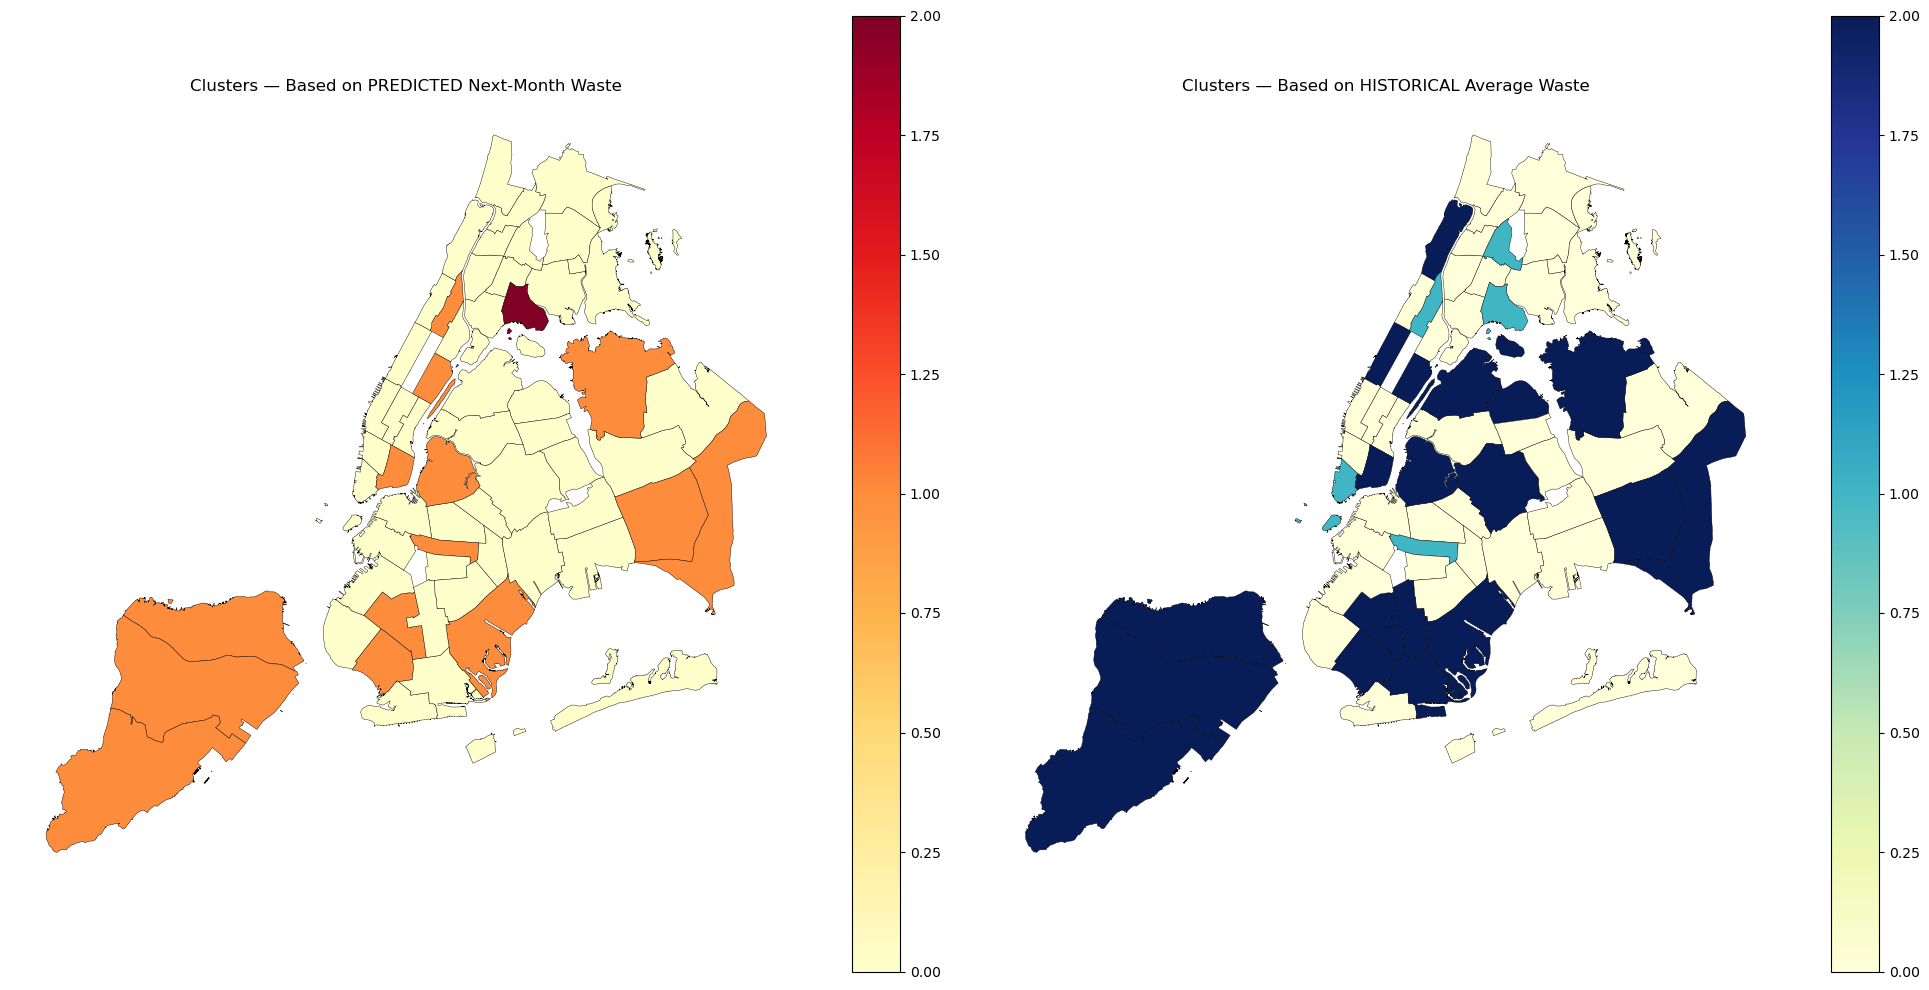

In [63]:
merged = districts_gdf.merge(district_summary, on="BoroCd")

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

merged.plot(column="kmeans_cluster", cmap="YlOrRd", legend=True, ax=axes[0], edgecolor="black", linewidth=0.3)
axes[0].set_title("Clusters — Based on PREDICTED Next-Month Waste")
axes[0].axis("off")

merged.plot(column="kmeans_cluster_HISTORICAL", cmap="YlGnBu", legend=True, ax=axes[1], edgecolor="black", linewidth=0.3)
axes[1].set_title("Clusters — Based on HISTORICAL Average Waste")
axes[1].axis("off")

plt.tight_layout()
plt.savefig(PROCESSED / "kmeans_cluster_map_comparison.png", dpi=150)
plt.show()

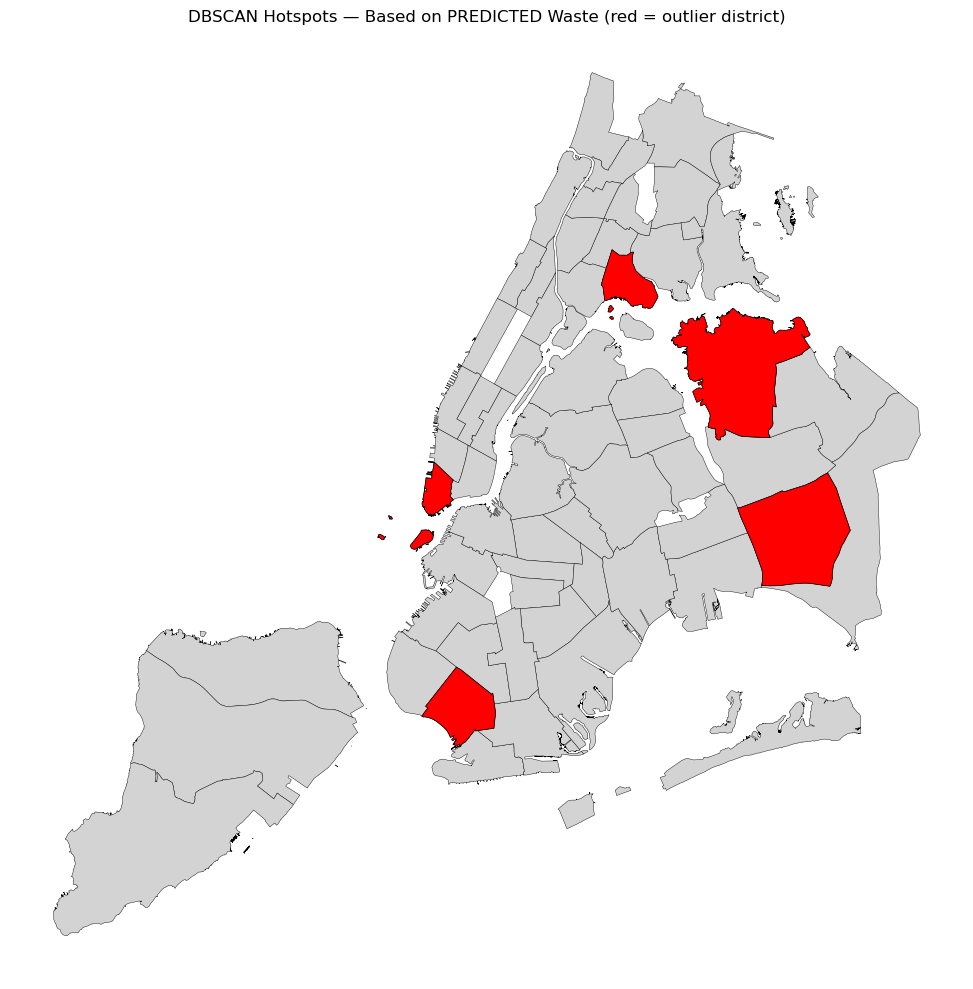

In [64]:
fig, ax = plt.subplots(figsize=(10, 10))
merged.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.3)
merged[merged["dbscan_cluster"] == -1].plot(ax=ax, color="red", edgecolor="black", linewidth=0.5)
ax.set_title("DBSCAN Hotspots — Based on PREDICTED Waste (red = outlier district)")
ax.axis("off")
plt.tight_layout()
plt.savefig(PROCESSED / "dbscan_hotspot_map.png", dpi=150)
plt.show()

In [65]:
district_summary.to_parquet(PROCESSED / "district_clusters.parquet", index=False)
print("Saved district_clusters.parquet (clusters based on PREDICTED waste)")

Saved district_clusters.parquet (clusters based on PREDICTED waste)


## Land-Use Categorization
Rule-based heuristic combining **PREDICTED** waste level (tier) with **HISTORICAL** volatility (stability pattern). This is a heuristic, not ground-truth zoning data — stated explicitly for the report.

In [66]:
def assign_landuse(row):
    level = row["cluster_label"]       # based on PREDICTED next-month waste
    cv = row["hist_cv"]                # based on HISTORICAL volatility

    if level == "Low Waste":
        return "Residential" if cv < 0.20 else "Institutional"
    elif level == "Medium Waste":
        return "Mixed-Use" if cv < 0.20 else "Commercial"
    else:
        return "Industrial" if cv < 0.20 else "Market Area"

district_summary["land_use_category"] = district_summary.apply(assign_landuse, axis=1)

print("Land-use category = PREDICTED waste level (tier) + HISTORICAL volatility (stability pattern)")
district_summary["land_use_category"].value_counts()

Land-use category = PREDICTED waste level (tier) + HISTORICAL volatility (stability pattern)


land_use_category
Residential      42
Mixed-Use        11
Commercial        3
Institutional     2
Market Area       1
Name: count, dtype: int64

In [67]:
category_stats_pred = district_summary.groupby("land_use_category").agg(
    num_blocks=("BoroCd", "count"),
    total_waste=("predicted_tons", "sum"),
    avg_waste=("predicted_tons", "mean"),
).reset_index()
category_stats_pred["pct_of_city_total"] = category_stats_pred["total_waste"] / category_stats_pred["total_waste"].sum() * 100
category_stats_pred = category_stats_pred.sort_values("total_waste", ascending=False)

category_stats_hist = district_summary.groupby("land_use_category").agg(
    num_blocks=("BoroCd", "count"),
    total_waste=("hist_avg", "sum"),
    avg_waste=("hist_avg", "mean"),
).reset_index()
category_stats_hist["pct_of_city_total"] = category_stats_hist["total_waste"] / category_stats_hist["total_waste"].sum() * 100
category_stats_hist = category_stats_hist.sort_values("total_waste", ascending=False)

print("PREDICTED (next month):")
display(category_stats_pred)
print("\nHISTORICAL (all-time average):")
display(category_stats_hist)

PREDICTED (next month):


,land_use_category,num_blocks,total_waste,avg_waste,pct_of_city_total
4,Residential,42,191133.430323,4550.795960,61.278370
3,Mixed-Use,11,85717.772911,7792.524810,27.481563
0,Commercial,3,20426.462483,6808.820828,6.548830
2,Market Area,1,8607.867505,8607.867505,2.759727
1,Institutional,2,6024.572721,3012.286361,1.931509



HISTORICAL (all-time average):


,land_use_category,num_blocks,total_waste,avg_waste,pct_of_city_total
4,Residential,42,187543.837091,4465.329455,63.230813
3,Mixed-Use,11,80681.997287,7334.727026,27.202111
0,Commercial,3,16963.202660,5654.400887,5.719181
2,Market Area,1,5837.756934,5837.756934,1.968212
1,Institutional,2,5575.178383,2787.589191,1.879684


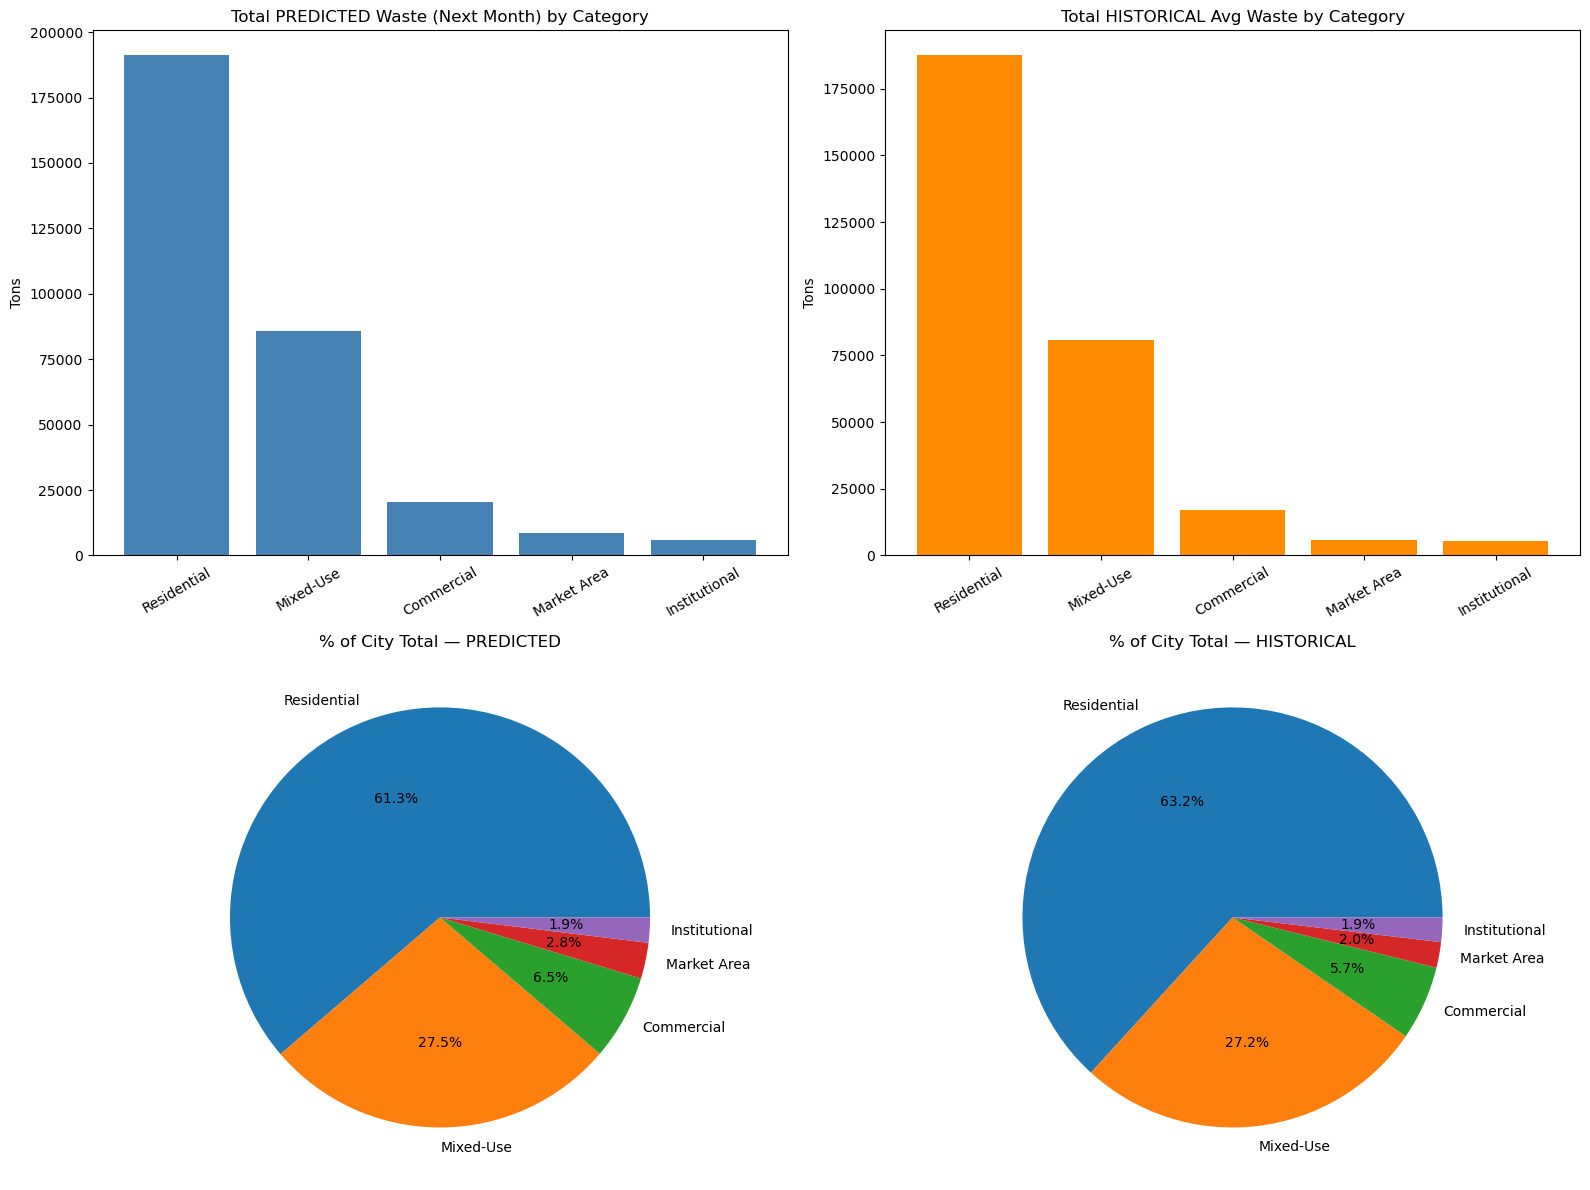

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].bar(category_stats_pred["land_use_category"], category_stats_pred["total_waste"], color="steelblue")
axes[0, 0].set_title("Total PREDICTED Waste (Next Month) by Category")
axes[0, 0].set_ylabel("Tons")
axes[0, 0].tick_params(axis="x", rotation=30)

axes[0, 1].bar(category_stats_hist["land_use_category"], category_stats_hist["total_waste"], color="darkorange")
axes[0, 1].set_title("Total HISTORICAL Avg Waste by Category")
axes[0, 1].set_ylabel("Tons")
axes[0, 1].tick_params(axis="x", rotation=30)

axes[1, 0].pie(category_stats_pred["pct_of_city_total"], labels=category_stats_pred["land_use_category"], autopct="%1.1f%%")
axes[1, 0].set_title("% of City Total — PREDICTED")

axes[1, 1].pie(category_stats_hist["pct_of_city_total"], labels=category_stats_hist["land_use_category"], autopct="%1.1f%%")
axes[1, 1].set_title("% of City Total — HISTORICAL")

plt.tight_layout()
plt.savefig(PROCESSED / "landuse_category_stats.png", dpi=150)
plt.show()

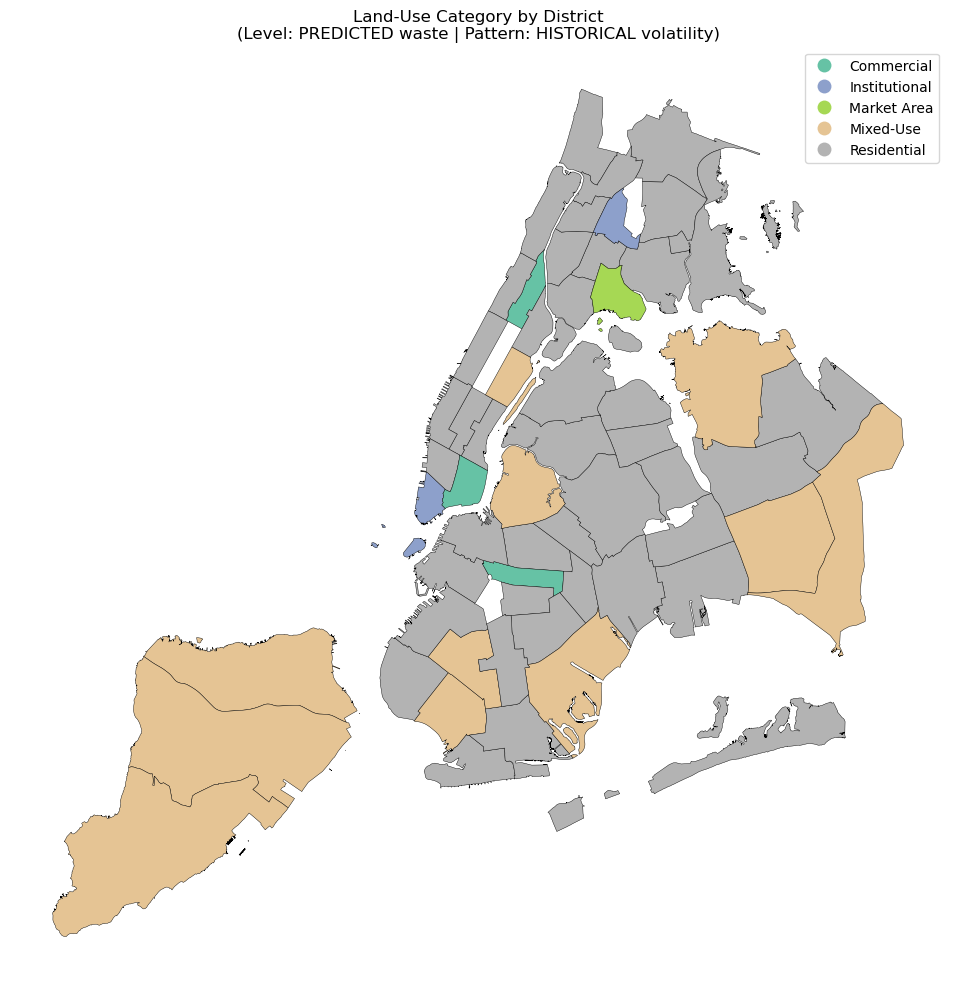

In [69]:
merged_landuse = districts_gdf.merge(district_summary, on="BoroCd")

fig, ax = plt.subplots(figsize=(10, 10))
merged_landuse.plot(column="land_use_category", categorical=True, legend=True, ax=ax, edgecolor="black", linewidth=0.3, cmap="Set2")
ax.set_title("Land-Use Category by District\n(Level: PREDICTED waste | Pattern: HISTORICAL volatility)")
ax.axis("off")
plt.tight_layout()
plt.savefig(PROCESSED / "landuse_category_map.png", dpi=150)
plt.show()

In [70]:
district_summary.to_parquet(PROCESSED / "district_clusters.parquet", index=False)
category_stats_pred.to_csv(PROCESSED / "category_stats_predicted.csv", index=False)
category_stats_hist.to_csv(PROCESSED / "category_stats_historical.csv", index=False)
print("Stage 3 complete. Saved PREDICTED and HISTORICAL comparison outputs.")

Stage 3 complete. Saved PREDICTED and HISTORICAL comparison outputs.
